#  04. Stress Test: Load Balancer at Different Request Rates

**Theme**: Stress test the Load Balancer at **different arrival rates** to understand system capacity and breaking points.

## Key Insight
- Low rates → system handles load easily
- Medium rates → queues start forming
- High rates → SLA violations and forced diversions

---
## 1. Common Setup

In [2]:
import sys
from pathlib import Path
# Path setup
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent.parent
ARTEMIS_DIR = ROOT_DIR / 'artemis_final'
CHECKPOINTS_DIR = ARTEMIS_DIR / 'checkpoints'
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ARTEMIS_DIR))

In [3]:
import matplotlib.pyplot as plt
import time 
import pandas as pd

# Imports
from sqlalchemy import create_engine, text
from artemis_final.load_balancer.public_api import (
    load_capacity_config,
    StatsRegistry,
    ArtemisLoadBalancer,
    RouterOutput,
    SchedulingContext,
    ModelCapacityConfig
)
from artemis_final.ares.configs.db_config import DB_URL, TABLES

DB_AVAILABLE = True

# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None

Device: mps


In [4]:
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


In [5]:
# Load many samples for stress test
def load_samples(n=100):
    if not DB_AVAILABLE:
        return [{'sample_id': f'sample_{i}', 'prompt': f'Sample prompt {i}', 'router_task': 'vqa'} for i in range(n)]
    try:
        engine = create_engine(DB_URL)
        with engine.connect() as conn:
            result = conn.execute(text(f"SELECT sample_id, prompt_text, router_task FROM {TABLES['samples']} WHERE prompt_text IS NOT NULL ORDER BY RANDOM() LIMIT {n}"))
            return [{'sample_id': r[0], 'prompt': r[1], 'router_task': r[2] or 'vqa'} for r in result.fetchall()]
    except Exception as e:
        print(f"️ DB Error: {e}")
        return [{'sample_id': f'sample_{i}', 'prompt': f'Prompt {i}', 'router_task': 'vqa'} for i in range(n)]

samples = load_samples(100)
print(f" Loaded {len(samples)} samples for stress testing")

 Loaded 100 samples for stress testing


In [6]:
# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

Device: mps
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


In [10]:
# Load Capacity Config (Updated)
from artemis_final.load_balancer.public_api import load_capacity_config

try:
    # Try to load the config that matches the router's models
    capacity_config = load_capacity_config('multitask_router_v1')
    print(" Loaded capacity config for multitask_router_v1")
except Exception as e:
    print(f"️ Failed to load multitask_router_v1 config: {e}")
    print("   Falling back to default capacity config (gemma, qwen, deepseek)")
    # Fallback to a known good config if the specific one isn't found
    capacity_config = {
        'gemma_3_27b': {'max_capacity': 100, 'cost_per_token': 0.0001},
        'qwen_1_8b': {'max_capacity': 100, 'cost_per_token': 0.00005},
        'deepseek_6_7b': {'max_capacity': 100, 'cost_per_token': 0.00008},
    }
    print("   Using hardcoded fallback capacity config.")

print("Capacity Config:")                         
for model, config in capacity_config.items():
    print(f"  {model}: {config}")

# Placeholder for VLM inference, if applicable
call_vlm = True # Set to True if VLM inference is desired
print(f"\nVLM INFERENCE: Skipped (call_vlm={call_vlm})\n")


 Loaded capacity config for multitask_router_v1
Capacity Config:
  gemma_3_27b: ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, min_replicas=1, max_replicas=2, sla_ms=4000, max_qps_per_replica=0.5, cost_per_request_usd=0.0005, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen3_vl_8b_thinking: ModelCapacityConfig(model_name='qwen3_vl_8b_thinking', base_latency_ms=1200, min_replicas=1, max_replicas=3, sla_ms=3000, max_qps_per_replica=0.8, cost_per_request_usd=0.003, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen2_5_vl_7b: ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, min_replicas=1, max_replicas=4, sla_ms=2500, max_qps_per_replica=1.2, cost_per_request_usd=0.0004, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen2_5_vl

---
## 2. Stress Test at Different Arrival Rates

In [11]:
import time 
import pandas as pd
def run_stress_test(samples, arrival_rate_rps, model_configs, stats, sla_ms=1500):
    """
    Run stress test at a specific arrival rate.
    
    Args:
        arrival_rate_rps: Requests per second
    """
    lb = ArtemisLoadBalancer(
        model_configs=model_configs,
        stats_registry=stats,
        latency_sla_ms={'default': sla_ms},
        scheduling_mode='capacity_aware',
        simulation_only=True,
    )
    
    inter_arrival_ms = 1000.0 / arrival_rate_rps  # ms between requests
    results = []
    current_time = time.time() * 1000
    
    for i, sample in enumerate(samples):
        current_time += inter_arrival_ms
        
        # Router prediction
        if router:
            try:
                rr = router.route(prompt=sample['prompt'], mode='balanced')
                probs, preferred = rr['probs'], rr['chosen_model']
            except:
                models = list(model_configs.keys())
                probs = {m: 1.0/len(models) for m in models}
                preferred = models[1]
        else:
            models = list(model_configs.keys())
            probs = {m: 1.0/len(models) for m in models}
            preferred = models[1]  # Prefer medium/slow model
        
        ro = RouterOutput(
            sample_id=sample['sample_id'], task_type=sample['router_task'],
            router_probs=probs, preferred_model=preferred, max_prob=probs.get(preferred, 0.33)
        )
        ctx = SchedulingContext(arrival_ts_ms=current_time, load_profile=f'{arrival_rate_rps}rps')
        dec = lb.schedule(ro, ctx)
        # === VLM Inference (Injected) ===
        if 'call_vlm' in locals() and call_vlm and vlm_client:
            # Try to get image data
            img_data = sample.get('image_bytes') or sample.get('image')
            if img_data:
                try:
                    # If bytes, convert to PIL or pass as is (Client handles it)
                    from io import BytesIO
                    from PIL import Image
                    if isinstance(img_data, bytes):
                        img_input = Image.open(BytesIO(img_data))
                    else:
                        img_input = img_data
                        
                    print(f"   Invoking VLM ({dec.chosen_model})...")
                    vlm_result = vlm_client.vlm.run_image(
                        image=img_input,
                        text=sample['prompt'],
                        models=[dec.chosen_model],
                        max_tokens=200
                    )
                    
                    # Extract result
                    model_resp = vlm_result.get(dec.chosen_model, {})
                    if model_resp.get('ok'):
                        print(f"   VLM Response: {model_resp.get('response_text')[:100]}...")
                    else:
                        print(f"   VLM Error: {model_resp.get('error')}")
                        
                except Exception as e:
                    print(f"   VLM call failed: {e}")
            else:
               pass # No image data for VLM


        
        results.append({
            'request_num': i,
            'arrival_rate': arrival_rate_rps,
            'queue_delay_ms': dec.queue_delay_ms,
            'service_time_ms': dec.service_time_ms,
            'total_latency_ms': dec.total_latency_ms,
            'sla_violated': dec.sla_violated,
            'chosen_model': dec.chosen_model,
            'router_choice': preferred,
            'diverted': dec.chosen_model != preferred,
        })
    
    return pd.DataFrame(results)

In [ ]:

# === VLM Client Setup ===
from artemis_final.utils.vlm_client_factory import get_vlm_client

# Initialize Client
# simulation_only=False means we try to load real models from config.
# If config is missing or fails, it falls back to Mock.
# Note: In the notebooks below, specific simulation_only flags might override this intention for the Load Balancer,
# but we prepare the client here.
try:
    # Check if 'lb' exists and use its setting, otherwise default to False (Real)
    sim_mode = lb.simulation_only if 'lb' in locals() else False
    vlm_client = get_vlm_client(simulation_only=sim_mode)
    print(f" VLM Client initialized: {type(vlm_client).__name__}")
except Exception as e:
    print(f" Could not initialize VLM client: {e}")
    vlm_client = None


In [15]:
# Load Balancer & Config
try:
    model_configs = load_capacity_config()
except:
    model_configs = {
        'qwen2_5_vl_7b': ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, cost_per_request_usd=0.005),
        'gemma_3_27b': ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, cost_per_request_usd=0.01),
        'deepseek_ocr': ModelCapacityConfig(model_name='deepseek_ocr', base_latency_ms=400, cost_per_request_usd=0.002, sla_ms=1000),
    }
stats = StatsRegistry()

In [16]:
# Test different arrival rates
arrival_rates = [1, 5, 10, 20, 50]  # requests per second
SLA_MS = 1500

all_results = []

print(f" Stress Testing at Different Arrival Rates")
print(f"   SLA: {SLA_MS}ms")
print(f"   Samples per test: {len(samples)}")
print("="*60)

for rate in arrival_rates:
    print(f"\n⏳ Testing {rate} req/s...")
    df_rate = run_stress_test(samples, rate, model_configs, stats, SLA_MS)
    all_results.append(df_rate)
    
    print(f"   Avg Latency: {df_rate['total_latency_ms'].mean():.0f}ms")
    print(f"   P95 Latency: {df_rate['total_latency_ms'].quantile(0.95):.0f}ms")
    print(f"   Max Queue Delay: {df_rate['queue_delay_ms'].max():.0f}ms")
    print(f"   SLA Violations: {df_rate['sla_violated'].sum()} ({df_rate['sla_violated'].mean():.1%})")
    print(f"   Diversions: {df_rate['diverted'].sum()} ({df_rate['diverted'].mean():.1%})")

df_all = pd.concat(all_results, ignore_index=True)

 Stress Testing at Different Arrival Rates
   SLA: 1500ms
   Samples per test: 100

⏳ Testing 1 req/s...
   Avg Latency: 10918ms
   P95 Latency: 32780ms
   Max Queue Delay: 0ms
   SLA Violations: 94 (94.0%)
   Diversions: 6 (6.0%)

⏳ Testing 5 req/s...
   Avg Latency: 10918ms
   P95 Latency: 32780ms
   Max Queue Delay: 0ms
   SLA Violations: 94 (94.0%)
   Diversions: 6 (6.0%)

⏳ Testing 10 req/s...
   Avg Latency: 10918ms
   P95 Latency: 32780ms
   Max Queue Delay: 0ms
   SLA Violations: 94 (94.0%)
   Diversions: 6 (6.0%)

⏳ Testing 20 req/s...
   Avg Latency: 10918ms
   P95 Latency: 32780ms
   Max Queue Delay: 0ms
   SLA Violations: 94 (94.0%)
   Diversions: 6 (6.0%)

⏳ Testing 50 req/s...
   Avg Latency: 10918ms
   P95 Latency: 32780ms
   Max Queue Delay: 0ms
   SLA Violations: 94 (94.0%)
   Diversions: 6 (6.0%)


---
## 3. Summary Statistics

In [17]:
summary = df_all.groupby('arrival_rate').agg({
    'total_latency_ms': ['mean', lambda x: x.quantile(0.95), 'max'],
    'queue_delay_ms': ['mean', 'max'],
    'sla_violated': 'mean',
    'diverted': 'mean',
}).round(2)

summary.columns = ['avg_latency', 'p95_latency', 'max_latency', 'avg_queue', 'max_queue', 'sla_violation_rate', 'diversion_rate']

print("\n Stress Test Summary:")
display(summary)


 Stress Test Summary:


,avg_latency,p95_latency,max_latency,avg_queue,max_queue,sla_violation_rate,diversion_rate
arrival_rate,,,,,,,
1,10918.25,32779.73,38729.74,0.0,0.0,0.94,0.06
5,10918.25,32779.73,38729.74,0.0,0.0,0.94,0.06
10,10918.25,32779.73,38729.74,0.0,0.0,0.94,0.06
20,10918.25,32779.73,38729.74,0.0,0.0,0.94,0.06
50,10918.25,32779.73,38729.74,0.0,0.0,0.94,0.06


---
## 4. Visualizations

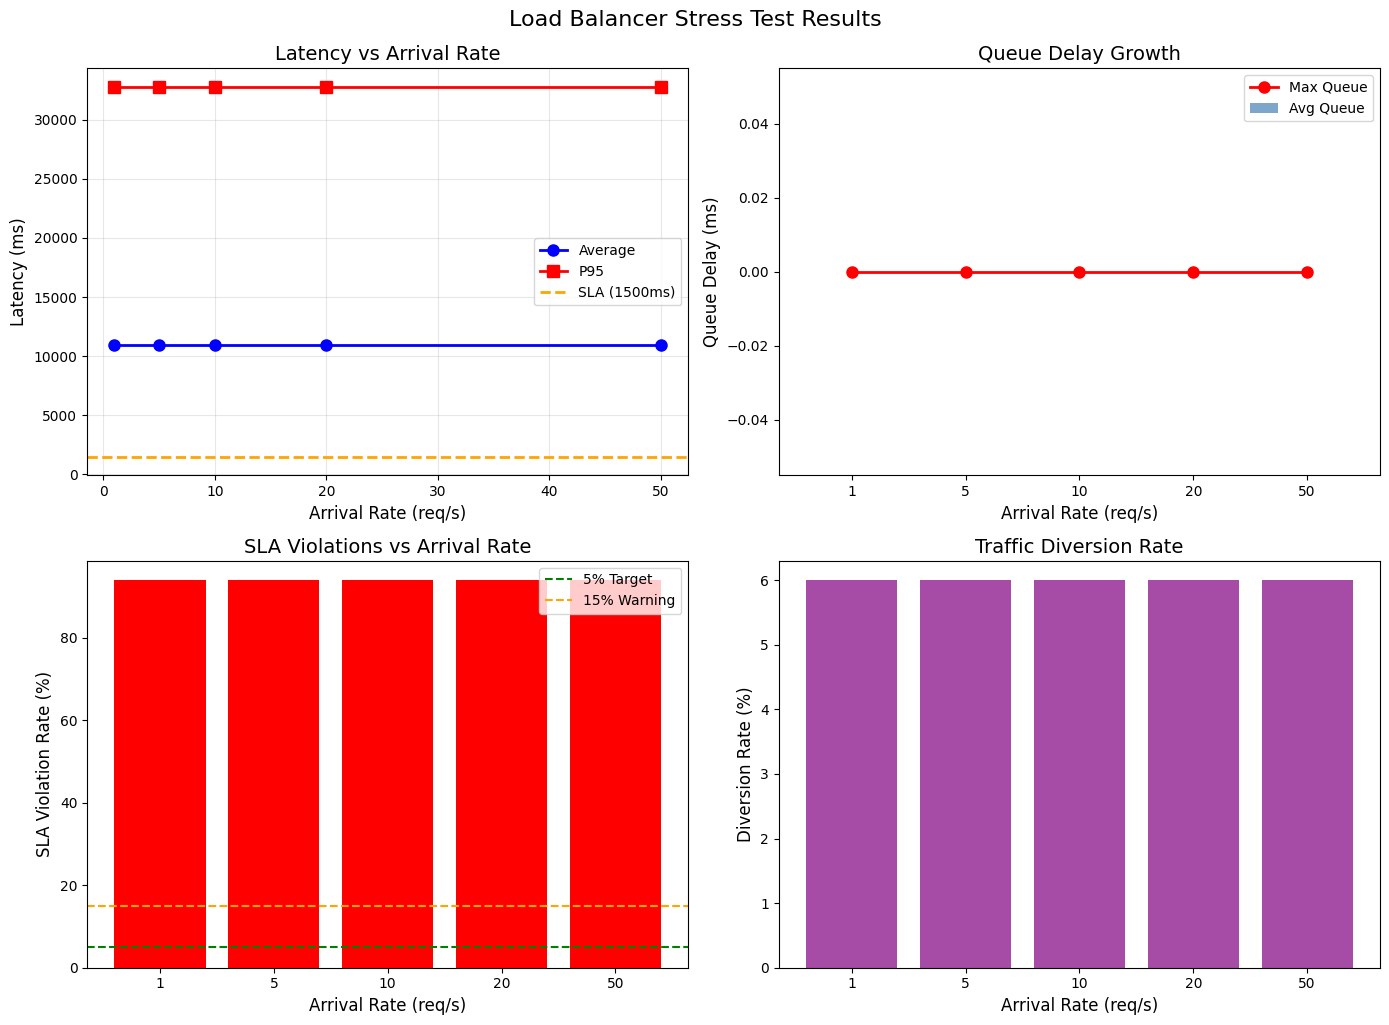

In [18]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Latency vs Arrival Rate
ax1 = axes[0, 0]
ax1.plot(summary.index, summary['avg_latency'], 'b-o', linewidth=2, markersize=8, label='Average')
ax1.plot(summary.index, summary['p95_latency'], 'r-s', linewidth=2, markersize=8, label='P95')
ax1.axhline(y=SLA_MS, color='orange', linestyle='--', linewidth=2, label=f'SLA ({SLA_MS}ms)')
ax1.set_xlabel('Arrival Rate (req/s)', fontsize=12)
ax1.set_ylabel('Latency (ms)', fontsize=12)
ax1.set_title('Latency vs Arrival Rate', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Queue Delay vs Arrival Rate
ax2 = axes[0, 1]
ax2.bar(summary.index.astype(str), summary['avg_queue'], color='steelblue', alpha=0.7, label='Avg Queue')
ax2.plot(range(len(summary)), summary['max_queue'], 'ro-', linewidth=2, markersize=8, label='Max Queue')
ax2.set_xlabel('Arrival Rate (req/s)', fontsize=12)
ax2.set_ylabel('Queue Delay (ms)', fontsize=12)
ax2.set_title('Queue Delay Growth', fontsize=14)
ax2.legend()

# Plot 3: SLA Violation Rate
ax3 = axes[1, 0]
colors = ['green' if v < 0.05 else ('orange' if v < 0.15 else 'red') for v in summary['sla_violation_rate']]
ax3.bar(summary.index.astype(str), summary['sla_violation_rate'] * 100, color=colors)
ax3.axhline(y=5, color='green', linestyle='--', label='5% Target')
ax3.axhline(y=15, color='orange', linestyle='--', label='15% Warning')
ax3.set_xlabel('Arrival Rate (req/s)', fontsize=12)
ax3.set_ylabel('SLA Violation Rate (%)', fontsize=12)
ax3.set_title('SLA Violations vs Arrival Rate', fontsize=14)
ax3.legend()

# Plot 4: Diversion Rate
ax4 = axes[1, 1]
ax4.bar(summary.index.astype(str), summary['diversion_rate'] * 100, color='purple', alpha=0.7)
ax4.set_xlabel('Arrival Rate (req/s)', fontsize=12)
ax4.set_ylabel('Diversion Rate (%)', fontsize=12)
ax4.set_title('Traffic Diversion Rate', fontsize=14)

plt.tight_layout()
plt.suptitle('Load Balancer Stress Test Results', fontsize=16, y=1.02)
plt.show()

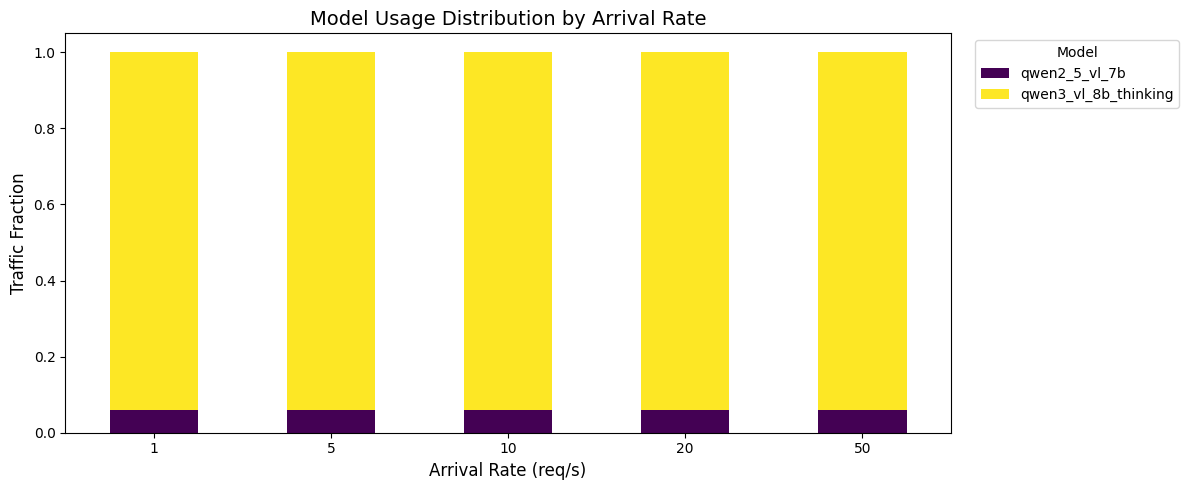


 Insight: At higher rates, LB shifts traffic to faster models to maintain SLAs.


In [19]:
# Model usage at different rates
fig, ax = plt.subplots(figsize=(12, 5))

model_usage = df_all.groupby(['arrival_rate', 'chosen_model']).size().unstack(fill_value=0)
model_usage_pct = model_usage.div(model_usage.sum(axis=1), axis=0)

model_usage_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_xlabel('Arrival Rate (req/s)', fontsize=12)
ax.set_ylabel('Traffic Fraction', fontsize=12)
ax.set_title('Model Usage Distribution by Arrival Rate', fontsize=14)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n Insight: At higher rates, LB shifts traffic to faster models to maintain SLAs.")

---
## Summary

This notebook demonstrated:
- **Low arrival rates** → System handles load easily, minimal queues
- **Medium rates** → Queues start forming, latency increases
- **High rates** → SLA violations occur, LB diverts to faster models
- The LB automatically adapts to load conditions